In [3]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt

import sys
sys.path.insert(1, r'C:\Users\tomaz.bregar\Desktop\PhD\pyFBS')

import numpy as np

from pyfbs.io import Impacts,Channels,Sensors
from pyfbs.vpt import VPT
import os


path_list = os.path.abspath('__file__').split(os.sep)
script_directory = path_list[0:len(path_list)-2]

example_xlsx = "/".join(script_directory) + "/" + "data/test_geometry.xlsx"
example_xlsx

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'C:/Users/tomaz.bregar/Desktop/PhD/pyFBS/data/test_geometry.xlsx'

In [4]:
from pyfbs.io import Sensors,Impacts

ASensors = Sensors(example_xlsx,"Sensors", "Channels")
AImpacts = Impacts(example_xlsx,"Impacts")


from pyfbs.util import read_uff_file


example_frf = "/".join(script_directory) + "/" + "data/rawFRF.uf"
rawData = read_uff_file(example_frf)

example_frf = "/".join(script_directory) + "/" + "data/rawCoh.uf"
rawCoh = read_uff_file(example_frf)


from pyfbs.frf import FRF
import pandas as pd
import numpy as np


Y = FRF()
Y.from_series_to_matrix(rawData,ASensors,AImpacts,_coh = rawCoh)


ggdfgfd
[[-0.9999999542070669, 0.0003026315650896483, 0], [-0.9999999542070666, 0.0003026315650894521, 0], [-0.9999999542070667, 0.0003026315650890052, 0], [-0.0002999999865016885, -0.999999955000003, 0], [0.0002999997989999719, 0.9999999550000593, 0], [0.00029999979900009646, 0.9999999550000593, 0], [0.0, 0.0, -1], [0.0, 0.0, -1], [0.0, 0.0, -1], [1.0, 0.0, 0], [-1.0, 0.0, 0], [-1.0, 0.0, 0], [0.0, -1.0, 0], [0.0, 1.0, 0], [0.0, 1.0, 0], [0.0, 0.0, -1], [0.0, 0.0, -1], [0.0, 0.0, -1], [1.0, 0.0, 0], [1.0, 0.0, 0], [1.0, 0.0, 0], [0.0, -1.0, 0], [0.0, -1.0, 0], [0.0, 1.0, 0], [0.0, 0.0, -1], [0.0, 0.0, -1], [0.0, 0.0, -1]]
ggdfgfd
[array([ 0., -1.,  0.]), array([1., 0., 0.]), array([0., 0., 1.]), array([0., 0., 1.]), array([3.03333319e-04, 9.99999954e-01, 0.00000000e+00]), array([-9.99999954e-01,  3.03333319e-04,  0.00000000e+00]), array([0., 0., 1.]), array([-3.02631565e-04, -9.99999954e-01,  0.00000000e+00]), array([ 9.99999954e-01, -3.02631565e-04,  0.00000000e+00]), array([ 0., -1.

In [15]:
print(np.mean(a))

0.6837886804487423


In [7]:
vpt = VPT(example_xlsx)
vpt.apply_VPT(Y)
vpt.consistency([1],[3])

FRF = vpt.vptData
_freq = vpt.vptFreqs

FRFvp = FRF[:18,:18]

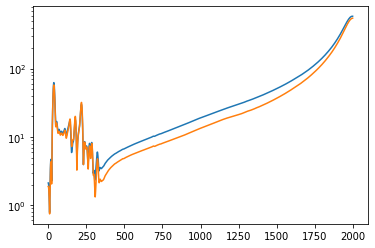

In [14]:
plt.semilogy(_freq,np.abs(FRF[1,5]));
plt.semilogy(_freq,np.abs(FRF[5,1]));

In [10]:
def get_cohVP(freq, FRF_VP):
    """
    Get Matrix Coh
    """
    get1 = np.zeros(len(freq),dtype = complex)
    get2 = np.zeros(len(freq),dtype = complex)
    print(get2)
    a = FRF_VP.shape
    matrix = np.zeros((a[0],a[0]))

    for k in range(a[0]):
        for j in range(a[0]):
            get1 = np.zeros(len(freq),dtype = complex)
            get2 = np.zeros(len(freq),dtype = complex)
            for i in range(len(freq)):
                get1[i] = FRF_VP[k,j,i]
                get2[i] = FRF_VP[j,k,i]
                
            matrix[j,k] = coh_frf(get1,get2)
    return matrix

def coh_frf(h_num, h_exp,check = False):
    """
    :param h_num: numerični kompleksni vektor FRF
    :param h_exp: eksperimentalni kompleksni vektor FRF
    
    :return: vrednost coherence kriterija
    """
    
    h_numk = np.conjugate(h_num)
    h_expk = np.conjugate(h_exp)
    
    def vector(h_, h_K):
        """
        :param h_: kompleksni vektor FRF
        :param h_K: konjugirani kompleksni vektor FRF
        
        :return: vektorski produkt
        """
        
        vec = np.dot(h_, h_K)
        return vec

    coh = (h_num + h_exp)
    
    coh = np.abs(vector((h_num + h_exp), (h_numk + h_expk)))  / 2 / (vector(h_numk, h_num)+vector(h_expk, h_exp))
    coh_abs = np.abs(coh)
    
    if check:
        return coh,coh_abs
    else:
        return coh_abs

[0.+0.j 0.+0.j 0.+0.j ... 0.+0.j 0.+0.j 0.+0.j]


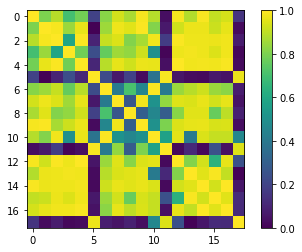

In [13]:
a = get_cohVP(_freq,FRFvp)

plt.imshow(a)
plt.colorbar()
plt.clim(0,1)

In [ ]:
plt.bar(np.arange(vpt.specific_impact.shape[0]),np.mean(vpt.specific_impact,axis = 2)[:,0])

In [ ]:
plt.bar(np.arange(vpt.specific_sensor.shape[0]),np.mean(vpt.specific_sensor,axis = 2)[:,0])

In [ ]:
plt.semilogy(Y.Freqs,np.abs(vpt.y[5,0]));
plt.semilogy(Y.Freqs,np.abs(vpt.y_f[5,0]));

plt.xlim(0,1500)

plt.figure()

plt.semilogy(Y.Freqs,np.abs(vpt.u[5,0]));
plt.semilogy(Y.Freqs,np.abs(vpt.u_f[5,0]));

plt.xlim(0,1500)

In [ ]:
np.mean(vpt.specific_impact,axis = 2)[:,0]

In [ ]:
plt.plot(Y.Freqs,vpt.specific_impact[0,0])
plt.xlim(0,3000)

plt.figure()

plt.plot(Y.Freqs,vpt.specific_sensor[0,0])
plt.xlim(0,3000)

In [ ]:
plt.plot(Y.Freqs,vpt.overall_impact)

plt.figure()
plt.plot(Y.Freqs,vpt.overall_sensor)

In [ ]:
plt.semilogy(Y.Freqs,np.abs(vpt.filt_Y[2,0]));
plt.semilogy(Y.Freqs,np.abs(vpt.nofilt_Y[2,0]));

plt.xlim(0,3000)

In [ ]:

plt.semilogy(vpt.vptFreqs,np.abs(vpt.vptData[-1,-1]))

plt.semilogy(Y.Freqs,np.abs(Y.Data[-1,-1]))

plt.xlim(0,2000)

In [ ]:
lim = 1500
a = np.zeros_like(Y.Data[:,:,:lim],dtype = complex)

for i in range(lim):
    a[:,:,i] = vpt_transf.Fu@Y.Data[:,:,i]


plt.plot(Y.Freqs[:lim],np.abs(a[6,1]))
plt.plot(Y.Freqs[:lim],np.abs(Y.Data[6,1][:lim]))


plt.tight_layout()


In [ ]:
import pickle


In [ ]:
filename = 'dogs'
outfile = open(filename,'wb')
pickle.dump(Y,outfile)
outfile.close()

In [ ]:
infile = open(filename,'rb')
new_dict = pickle.load(infile)
infile.close()

In [ ]:
vars(new_dict.Channels[0])